In [1]:
"""
Dynamic Routing Neural Architecture v2
=======================================
Fixes:
1. InputUnit now actually reads the input
2. FunctionalUnit keys gradient fixed
3. Dataset is region-based — geometry determines task deterministically
"""

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

In [2]:
HIDDEN_DIM  = 4
MAX_STEPS   = 10
NUM_UNITS   = 3
INPUT_DIM   = 2     
BATCH_SIZE  = 64
EPOCHS      = 600
LR          = 1e-3
ENTROPY_W   = 0.01
step_penalty_w=0.0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:

# ─────────────────────────────────────────────
# DATASET — region based, no random task assignment
# ─────────────────────────────────────────────

def rotate(x, theta=np.pi/4):
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    return x @ R.T

def scale(x, factor=2.0):
    return x * factor

def reflect(x):
    return x * np.array([1, -1])

def generate_dataset(n=2000):
    X = np.random.randn(n, 2).astype(np.float32)
    Y = np.zeros((n, 2), dtype=np.float32)
    tasks = np.zeros(n, dtype=int)
    paths = []

    for i in range(n):
        x = X[i]
        # angle determines task — same x always gets same task
        angle_deg = np.degrees(np.arctan2(x[1], x[0]) % (2 * np.pi))

        if angle_deg < 120:
            tasks[i] = 0
            Y[i] = scale(rotate(x))            # path: A → B
            paths.append([1, 2])               # unit indices (0=output, 1=A, 2=B, 3=C)
        elif angle_deg < 240:
            tasks[i] = 1
            Y[i] = reflect(scale(x))           # path: B → C
            paths.append([2, 3])
        else:
            tasks[i] = 2
            Y[i] = scale(reflect(rotate(x)))   # path: A → C → B
            paths.append([1, 3, 2])

    return X, Y, tasks, paths


In [4]:
# ─────────────────────────────────────────────
# INPUT UNITS
# ─────────────────────────────────────────────

class InputUnit(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
        )
        self.tail = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, x):
        # FIX: actually read x, not zeros
        body_out = self.body(x)               # (1, hidden_dim)
        tail_out = self.tail(body_out)        # (1, hidden_dim)
        straight = x                          # (1, input_dim) — re-injected at every unit
        return tail_out, body_out, straight


In [5]:
# ─────────────────────────────────────────────
# OUTPUT UNITS
# ─────────────────────────────────────────────
class OutputUnit(nn.Module):
    def __init__(self, hidden_dim, output_dim=2):
        super().__init__()
        self.head = nn.Linear(INPUT_DIM, 1)
        self.body = nn.Sequential(
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.body(x)                   # (1, output_dim)

    def keys(self):
        # gradients flow through head and body weights
        return self.head(self.body[0].weight.T).T  # (1, hidden_dim)

In [6]:
# ─────────────────────────────────────────────
# FUNCTIONAL UNITS
# ─────────────────────────────────────────────

class FunctionalUnit(nn.Module):
    def __init__(self, hidden_dim, input_dim=2):
        super().__init__()
        self.head    = nn.Linear(2 * input_dim, 1)
        self.body_1  = nn.Sequential(nn.Linear(hidden_dim, input_dim), nn.ReLU())
        self.body_2  = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU())
        self.tail    = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, x, straight):
        out  = self.body_1(x)
        out  = straight + out                 # residual: re-inject original input
        out  = self.body_2(out)
        tail = self.tail(out)
        return out, tail

    def keys(self):
        # FIX: no .data.clone() — gradients flow through head
        return self.head(
            torch.cat([self.body_1[0].weight.T,
                       self.body_2[0].weight], dim=1)
        ).T                                   # (1, hidden_dim)



In [7]:

# ─────────────────────────────────────────────
# GRAPH MODEL
# ─────────────────────────────────────────────

class graphmodel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_units, max_steps):
        super().__init__()
        self.input_unit       = InputUnit(input_dim, hidden_dim)
        self.output_unit      = OutputUnit(hidden_dim)
        self.functional_units = nn.ModuleList([
            FunctionalUnit(hidden_dim, input_dim) for _ in range(num_units)
        ])
        self.temperature = 0.5
        self.max_steps   = max_steps

    def keys(self):
        k = {0: self.output_unit.keys()}
        for i, unit in enumerate(self.functional_units):
            k[i + 1] = unit.keys()
        return k

    def forward(self, x, verbose=False):
        tail_query, state, straight = self.input_unit(x)

        k_d        = self.keys()
        route_keys = torch.cat([k_d[k] for k in k_d], dim=0)  # (num_units+1, hidden_dim)

        entropy   = torch.tensor(0.0, device=x.device)
        final_out = None
        path      = []

        for step in range(self.max_steps):

            # Attention
            attn_scores = tail_query @ route_keys.T / self.temperature  # (1, 4)
            attn_probs  = F.softmax(attn_scores, dim=-1)
            entropy    += -(attn_probs * (attn_probs + 1e-8).log()).sum(-1).mean()

            # Gumbel-Softmax — discrete but differentiable
            selected_soft      = F.gumbel_softmax(attn_scores, tau=self.temperature, hard=True)
            output_gate        = selected_soft[:, 0:1]   # (1, 1)
            functional_weights = selected_soft[:, 1:]    # (1, num_units)

            path.append(selected_soft.argmax(dim=-1).item())

            # Output unit candidate
            output_candidate = self.output_unit(state)   # (1, 2)

            # Accumulate prediction when output gate fires
            if final_out is None:
                final_out = output_gate * output_candidate
            else:
                final_out = final_out + output_gate * output_candidate

            # Run all functional units in parallel
            func_outs, func_tails = [], []
            for unit in self.functional_units:
                o, t = unit(state, straight)
                func_outs.append(o)
                func_tails.append(t)

            func_stack = torch.stack(func_outs,  dim=1)  # (1, num_units, hidden_dim)
            tail_stack = torch.stack(func_tails, dim=1)

            fw         = functional_weights.unsqueeze(-1)
            state      = (func_stack * fw).sum(dim=1)
            tail_query = (tail_stack * fw).sum(dim=1)

            if verbose:
                label = "OUTPUT" if output_gate.item() > 0.5 else f"Unit {path[-1]}"
                print(f"  Step {step+1}: {label}  probs={attn_probs.detach().cpu().numpy().round(3)}")

            if output_gate.item() > 0.5:
                break

        entropy = entropy / (step + 1)
        return final_out, entropy, attn_scores, attn_probs, path


In [8]:


# ─────────────────────────────────────────────
# TRAINING
# ─────────────────────────────────────────────

def train(model, train_dl, epochs=300, lr=1e-3, entropy_w=0.0, min_steps=2, step_penalty_w=0.0):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_history, entropy_history = [], []

    print(f"{'Epoch':>6}  {'Loss':>10}  {'Entropy':>10}  {'Avg Steps':>10}")
    print("-" * 48)

    for epoch in range(epochs):
        model.train()
        epoch_loss    = 0
        epoch_entropy = 0
        epoch_steps   = 0

        for xb, yb in train_dl:
            optimizer.zero_grad()
            batch_loss    = torch.tensor(0.0, device=DEVICE)
            batch_entropy = torch.tensor(0.0, device=DEVICE)
            batch_steps   = 0

            for i in range(xb.shape[0]):
                xi = xb[i:i+1].to(DEVICE)
                yi = yb[i:i+1].to(DEVICE)

                out, entropy, _, _, path = model(xi)
                if out is None:
                    continue

                # Task loss
                task_loss = F.mse_loss(out, yi)

                # Step penalty — punish early termination
                steps_taken = len(path)
                if steps_taken < min_steps:
                    penalty = torch.tensor(
                        float(min_steps - steps_taken),
                        device=DEVICE
                    )
                else:
                    penalty = torch.tensor(0.0, device=DEVICE)

                sample_loss    = task_loss + step_penalty_w * penalty
                batch_loss    += sample_loss
                batch_entropy += entropy
                batch_steps   += steps_taken

            n             = xb.shape[0]
            batch_loss    = batch_loss / n
            batch_entropy = batch_entropy / n

            # Total loss — minimize task+penalty, maximize entropy
            loss = batch_loss - entropy_w * batch_entropy
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            epoch_loss    += batch_loss.item()
            epoch_entropy += batch_entropy.item()
            epoch_steps   += batch_steps / n

        avg_loss    = epoch_loss    / len(train_dl)
        avg_entropy = epoch_entropy / len(train_dl)
        avg_steps   = epoch_steps   / len(train_dl)

        loss_history.append(avg_loss)
        entropy_history.append(avg_entropy)

        if epoch % 25 == 0:
            print(f"{epoch:>6}  {avg_loss:>10.4f}  {avg_entropy:>10.4f}  {avg_steps:>10.2f}")

    return loss_history, entropy_history



In [9]:
# ─────────────────────────────────────────────
# EVALUATION
# ─────────────────────────────────────────────

def evaluate(model, X, Y, tasks, paths, n_samples=10):
    model.eval()
    print("\n── Routing Inspection (first samples per task) ──")
    print(f"{'Task':>6}  {'GT Path':>15}  {'Learned Path':>15}  {'MSE':>8}")
    print("-" * 50)

    seen = {0: 0, 1: 0, 2: 0}
    for i in range(len(X)):
        t = tasks[i]
        if seen[t] >= 3:
            continue
        seen[t] += 1

        xi = torch.tensor(X[i:i+1]).to(DEVICE)
        yi = torch.tensor(Y[i:i+1]).to(DEVICE)

        with torch.no_grad():
            out, _, _, _, path = model(xi)

        mse = F.mse_loss(out, yi).item()
        gt  = paths[i]
        print(f"{t:>6}  {str(gt):>15}  {str(path):>15}  {mse:>8.4f}")

        if all(v >= 3 for v in seen.values()):
            break


def plot_results(loss_history, entropy_history, X, tasks, model):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Loss
    axes[0].plot(loss_history)
    axes[0].set_title("Training Loss (MSE)")
    axes[0].set_xlabel("Epoch")
    axes[0].grid(True)

    # Entropy
    axes[1].plot(entropy_history, color='orange')
    axes[1].set_title("Routing Entropy")
    axes[1].set_xlabel("Epoch")
    axes[1].grid(True)

    # Routing by region
    model.eval()
    path_lengths = []
    for i in range(len(X)):
        xi = torch.tensor(X[i:i+1]).to(DEVICE)
        with torch.no_grad():
            _, _, _, _, path = model(xi)
        path_lengths.append(len(path))

    sc = axes[2].scatter(X[:, 0], X[:, 1],
                         c=path_lengths, cmap='viridis', alpha=0.5, s=8)
    plt.colorbar(sc, ax=axes[2])
    axes[2].set_title("Learned Path Length per Input")
    axes[2].grid(True)

    plt.tight_layout()
    plt.savefig("routing_results_v2.png", dpi=150)
    print("\nPlot saved.")
    plt.show()


Training on cpu

  Step 1: Unit 3  probs=[[0.257 0.333 0.095 0.315]]
  Step 2: Unit 1  probs=[[0.218 0.168 0.463 0.151]]
  Step 3: OUTPUT  probs=[[0.215 0.286 0.07  0.429]]
Sanity check — output: tensor([[0.7966, 0.3160]], grad_fn=<AddBackward0>), path: [3, 1, 0]

 Epoch        Loss     Entropy   Avg Steps
------------------------------------------------
     0      4.0460      1.2473        4.19
    25      1.9468      0.2730        3.94
    50      1.0309      0.2030        1.84
    75      0.5216      0.1325        2.01
   100      0.3265      0.1151        1.83
   125      0.2510      0.1159        1.84
   150      0.2589      0.1160        1.83
   175      0.2639      0.1378        1.74
   200      0.2229      0.1154        1.74
   225      0.2013      0.1102        1.73
   250      0.1984      0.1843        1.86
   275      0.1802      0.1492        1.95
   300      0.1500      0.1219        1.98
   325      0.1588      0.1156        1.97
   350      0.1104      0.0980        1.9

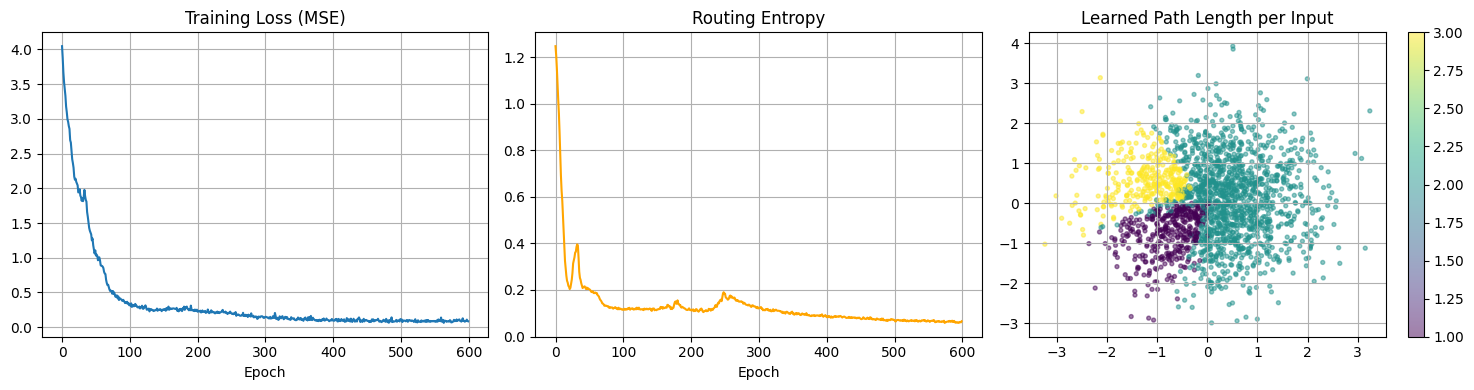

Model saved.


In [10]:


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────

if __name__ == "__main__":
    torch.manual_seed(42)
    np.random.seed(42)

    X, Y, tasks, paths = generate_dataset(2000)
    X_t = torch.tensor(X).to(DEVICE)
    Y_t = torch.tensor(Y).to(DEVICE)

    split    = int(len(X) * 0.9)
    train_ds = TensorDataset(X_t[:split], Y_t[:split])
    test_ds  = TensorDataset(X_t[split:], Y_t[split:])
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

    model = graphmodel(
        input_dim  = INPUT_DIM,
        hidden_dim = HIDDEN_DIM,
        num_units  = NUM_UNITS,
        max_steps  = MAX_STEPS
    ).to(DEVICE)

    print(f"Training on {DEVICE}\n")

    # Sanity check — single forward pass before training
    sample = X_t[0:1]
    out, ent, _, _, path = model(sample, verbose=True)
    print(f"Sanity check — output: {out}, path: {path}\n")

    loss_history, entropy_history = train(
        model, train_dl,
        epochs    = EPOCHS,
        lr        = LR,
        entropy_w = ENTROPY_W,
        step_penalty_w=step_penalty_w
    )

    evaluate(model, X, Y, tasks, paths)
    plot_results(loss_history, entropy_history, X, tasks, model)

    torch.save(model.state_dict(), "dynamic_routing_v2.pt")
    print("Model saved.")

In [11]:
'''
HIDDEN_DIM  = 4
MAX_STEPS   = 10
NUM_UNITS   = 3
INPUT_DIM   = 2     # pure geometry, no one-hot
BATCH_SIZE  = 64
EPOCHS      = 600
LR          = 1e-3
ENTROPY_W   = 0.01
step_penalty_w=0.1
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Training on cpu

  Step 1: Unit 3  probs=[[0.257 0.333 0.095 0.315]]
  Step 2: Unit 1  probs=[[0.218 0.168 0.463 0.151]]
  Step 3: OUTPUT  probs=[[0.215 0.286 0.07  0.429]]
Sanity check — output: tensor([[0.7966, 0.3160]], grad_fn=<AddBackward0>), path: [3, 1, 0]

 Epoch        Loss     Entropy   Avg Steps
------------------------------------------------
     0      4.0674      1.2473        4.19
    25      1.9506      0.2730        3.94
    50      1.0895      0.2030        1.84
    75      0.5589      0.1325        2.01
   100      0.3683      0.1151        1.83
   125      0.2900      0.1159        1.84
   150      0.2965      0.1160        1.83
   175      0.3071      0.1378        1.74
   200      0.2641      0.1154        1.74
   225      0.2432      0.1102        1.73
   250      0.2287      0.1843        1.86
   275      0.2020      0.1492        1.95
   300      0.1692      0.1219        1.98
   325      0.1768      0.1156        1.97
   350      0.1282      0.0980        1.98
   375      0.1224      0.0898        1.99
   400      0.1084      0.0829        2.02
   425      0.0974      0.0851        2.01
   450      0.1101      0.0761        1.99
   475      0.1169      0.0755        1.99
   500      0.1289      0.0709        1.99
   525      0.1159      0.0710        2.02
   550      0.1083      0.0681        2.00
   575      0.0878      0.0613        2.04

── Routing Inspection (first samples per task) ──
  Task          GT Path     Learned Path       MSE
--------------------------------------------------
     2        [1, 3, 2]           [1, 0]    0.0004
     0           [1, 2]           [3, 0]    0.0011
     1           [2, 3]              [0]    0.0424
     0           [1, 2]           [3, 0]    0.0019
     1           [2, 3]        [3, 2, 0]    0.0002
     1           [2, 3]              [0]    0.0667
     2        [1, 3, 2]           [1, 0]    0.0014
     2        [1, 3, 2]           [1, 0]    0.0010
     0           [1, 2]           [3, 0]    0.0029

Plot saved.'''

'\nHIDDEN_DIM  = 4\nMAX_STEPS   = 10\nNUM_UNITS   = 3\nINPUT_DIM   = 2     # pure geometry, no one-hot\nBATCH_SIZE  = 64\nEPOCHS      = 600\nLR          = 1e-3\nENTROPY_W   = 0.01\nstep_penalty_w=0.1\nDEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n\nTraining on cpu\n\n  Step 1: Unit 3  probs=[[0.257 0.333 0.095 0.315]]\n  Step 2: Unit 1  probs=[[0.218 0.168 0.463 0.151]]\n  Step 3: OUTPUT  probs=[[0.215 0.286 0.07  0.429]]\nSanity check — output: tensor([[0.7966, 0.3160]], grad_fn=<AddBackward0>), path: [3, 1, 0]\n\n Epoch        Loss     Entropy   Avg Steps\n------------------------------------------------\n     0      4.0674      1.2473        4.19\n    25      1.9506      0.2730        3.94\n    50      1.0895      0.2030        1.84\n    75      0.5589      0.1325        2.01\n   100      0.3683      0.1151        1.83\n   125      0.2900      0.1159        1.84\n   150      0.2965      0.1160        1.83\n   175      0.3071      0.1378        1.74\n   200  

In [12]:
'''
HIDDEN_DIM  = 4
MAX_STEPS   = 10
NUM_UNITS   = 3
INPUT_DIM   = 2     # pure geometry, no one-hot
BATCH_SIZE  = 64
EPOCHS      = 600
LR          = 1e-3
ENTROPY_W   = 0.0
step_penalty_w=0.0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


Training on cpu

  Step 1: Unit 3  probs=[[0.257 0.333 0.095 0.315]]
  Step 2: Unit 1  probs=[[0.218 0.168 0.463 0.151]]
  Step 3: OUTPUT  probs=[[0.215 0.286 0.07  0.429]]
Sanity check — output: tensor([[0.7966, 0.3160]], grad_fn=<AddBackward0>), path: [3, 1, 0]

 Epoch        Loss     Entropy   Avg Steps
------------------------------------------------
     0      4.0459      1.2471        4.19
    25      1.8053      0.2678        3.30
    50      1.1680      0.1752        1.64
    75      0.8955      0.1743        1.92
   100      0.7263      0.1296        2.18
   125      0.4226      0.1219        2.03
   150      0.2624      0.1269        2.14
   175      0.2086      0.0981        2.11
   200      0.2391      0.0821        2.06
   225      0.2043      0.0768        2.10
   250      0.2151      0.0700        2.07
   275      0.2192      0.0704        2.12
   300      0.1831      0.0690        2.16
   325      0.2298      0.0777        2.24
   350      0.1972      0.0698        2.18
   375      0.2992      0.0841        2.30
   400      0.2088      0.0710        2.27
   425      0.1557      0.0614        2.21
   450      0.2020      0.0679        2.28
   475      0.2176      0.0638        2.26
   500      0.1803      0.0632        2.30
   525      0.1640      0.0489        2.17
   550      0.1911      0.0496        2.20
   575      0.2135      0.0469        2.21

── Routing Inspection (first samples per task) ──
  Task          GT Path     Learned Path       MSE
--------------------------------------------------
     2        [1, 3, 2]           [3, 0]    0.0039
     0           [1, 2]           [3, 0]    0.0031
     1           [2, 3]        [3, 2, 0]    0.0075
     0           [1, 2]           [3, 0]    0.0674
     1           [2, 3]        [3, 2, 0]    0.0012
     1           [2, 3]        [3, 2, 0]    0.0020
     2        [1, 3, 2]              [0]    0.0043
     2        [1, 3, 2]           [3, 0]    1.9153
     0           [1, 2]           [3, 0]    0.0313

Plot saved.
'''

'\nHIDDEN_DIM  = 4\nMAX_STEPS   = 10\nNUM_UNITS   = 3\nINPUT_DIM   = 2     # pure geometry, no one-hot\nBATCH_SIZE  = 64\nEPOCHS      = 600\nLR          = 1e-3\nENTROPY_W   = 0.0\nstep_penalty_w=0.0\nDEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n\n\nTraining on cpu\n\n  Step 1: Unit 3  probs=[[0.257 0.333 0.095 0.315]]\n  Step 2: Unit 1  probs=[[0.218 0.168 0.463 0.151]]\n  Step 3: OUTPUT  probs=[[0.215 0.286 0.07  0.429]]\nSanity check — output: tensor([[0.7966, 0.3160]], grad_fn=<AddBackward0>), path: [3, 1, 0]\n\n Epoch        Loss     Entropy   Avg Steps\n------------------------------------------------\n     0      4.0459      1.2471        4.19\n    25      1.8053      0.2678        3.30\n    50      1.1680      0.1752        1.64\n    75      0.8955      0.1743        1.92\n   100      0.7263      0.1296        2.18\n   125      0.4226      0.1219        2.03\n   150      0.2624      0.1269        2.14\n   175      0.2086      0.0981        2.11\n   200 

In [13]:
'''
experiment 1:- 
conditions
:-HIDDEN_DIM  = 4
MAX_STEPS   = 10
NUM_UNITS   = 3
INPUT_DIM   = 2     # pure geometry, no one-hot
BATCH_SIZE  = 64
EPOCHS      = 600
LR          = 1e-3
ENTROPY_W   = 0.01
step_penalty_w=0.0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Training on cpu

  Step 1: Unit 3  probs=[[0.257 0.333 0.095 0.315]]
  Step 2: Unit 1  probs=[[0.218 0.168 0.463 0.151]]
  Step 3: OUTPUT  probs=[[0.215 0.286 0.07  0.429]]
Sanity check — output: tensor([[0.7966, 0.3160]], grad_fn=<AddBackward0>), path: [3, 1, 0]

 Epoch        Loss     Entropy   Avg Steps
------------------------------------------------
     0      4.0460      1.2473        4.19
    25      1.9468      0.2730        3.94
    50      1.0309      0.2030        1.84
    75      0.5216      0.1325        2.01
   100      0.3265      0.1151        1.83
   125      0.2510      0.1159        1.84
   150      0.2589      0.1160        1.83
   175      0.2639      0.1378        1.74
   200      0.2229      0.1154        1.74
   225      0.2013      0.1102        1.73
   250      0.1984      0.1843        1.86
   275      0.1802      0.1492        1.95
   300      0.1500      0.1219        1.98
   325      0.1588      0.1156        1.97
   350      0.1104      0.0980        1.98
   375      0.1043      0.0898        1.99
   400      0.0932      0.0829        2.02
   425      0.0811      0.0851        2.01
   450      0.0919      0.0761        1.99
   475      0.1004      0.0755        1.99
   500      0.1114      0.0709        1.99
   525      0.0996      0.0710        2.02
   550      0.0911      0.0681        2.00
   575      0.0722      0.0613        2.04

── Routing Inspection (first samples per task) ──
  Task          GT Path     Learned Path       MSE
--------------------------------------------------
     2        [1, 3, 2]           [1, 0]    0.0004
     0           [1, 2]           [3, 0]    0.0011
     1           [2, 3]              [0]    0.0424
     0           [1, 2]           [3, 0]    0.0019
     1           [2, 3]        [3, 2, 0]    0.0002
     1           [2, 3]              [0]    0.0667
     2        [1, 3, 2]           [1, 0]    0.0014
     2        [1, 3, 2]           [1, 0]    0.0010
     0           [1, 2]           [3, 0]    0.0029

Plot saved.'''

'\nexperiment 1:- \nconditions\n:-HIDDEN_DIM  = 4\nMAX_STEPS   = 10\nNUM_UNITS   = 3\nINPUT_DIM   = 2     # pure geometry, no one-hot\nBATCH_SIZE  = 64\nEPOCHS      = 600\nLR          = 1e-3\nENTROPY_W   = 0.01\nstep_penalty_w=0.0\nDEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")\nTraining on cpu\n\n  Step 1: Unit 3  probs=[[0.257 0.333 0.095 0.315]]\n  Step 2: Unit 1  probs=[[0.218 0.168 0.463 0.151]]\n  Step 3: OUTPUT  probs=[[0.215 0.286 0.07  0.429]]\nSanity check — output: tensor([[0.7966, 0.3160]], grad_fn=<AddBackward0>), path: [3, 1, 0]\n\n Epoch        Loss     Entropy   Avg Steps\n------------------------------------------------\n     0      4.0460      1.2473        4.19\n    25      1.9468      0.2730        3.94\n    50      1.0309      0.2030        1.84\n    75      0.5216      0.1325        2.01\n   100      0.3265      0.1151        1.83\n   125      0.2510      0.1159        1.84\n   150      0.2589      0.1160        1.83\n   175      0.2639     